In [22]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
# Load the dataset
df = pd.read_csv('../Data/Multiple_Linear_Regression.csv')

In [24]:
# Display the dataset
print(df.head())

   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830


In [25]:
# Check for missing values
print(df.isnull().sum())

age           0
experience    0
income        0
dtype: int64


In [26]:
# Descriptive statistics
print(df.describe())

              age  experience        income
count  100.000000  100.000000    100.000000
mean    41.650000    9.360000  45930.300000
std     11.215407    5.629145  11777.235399
min     23.000000    1.000000  27000.000000
25%     32.000000    5.000000  37222.500000
50%     41.000000    9.000000  44915.000000
75%     52.000000   13.000000  53040.000000
max     60.000000   25.000000  74580.000000


In [27]:
# Split the dataset into features and target variable
X = df.drop('income', axis=1)
y = df['income']

In [28]:
# Train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 150.31,1824.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.257e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [29]:
# Predict the target variable for the test set
y_pred = model.predict(X_test)

In [30]:
# Model Formula
print("Age Coefficients:", model.coef_[0])
print("Experience Coefficients:", model.coef_[1])
print("Intercept:", model.intercept_)
print("Income = {:.2f} + {:.2f}*age + {:.2f}*experience".format(model.intercept_, model.coef_[0], model.coef_[1]))

Age Coefficients: 150.31276131430988
Experience Coefficients: 1824.088877796096
Intercept: 22567.972239251147
Income = 22567.97 + 150.31*age + 1824.09*experience


In [31]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

Root Mean Squared Error: 2006.2897325001582
R-squared: 0.9716606573039159


In [32]:
# Example prediction
new_person = pd.DataFrame({'age': [30], 'experience': [5]})
predicted_income = model.predict(new_person)
print(f'Predicted income for age 30 and experience 5: {predicted_income[0]:.2f} ± {rmse:.2f}')

Predicted income for age 30 and experience 5: 36197.80 ± 2006.29


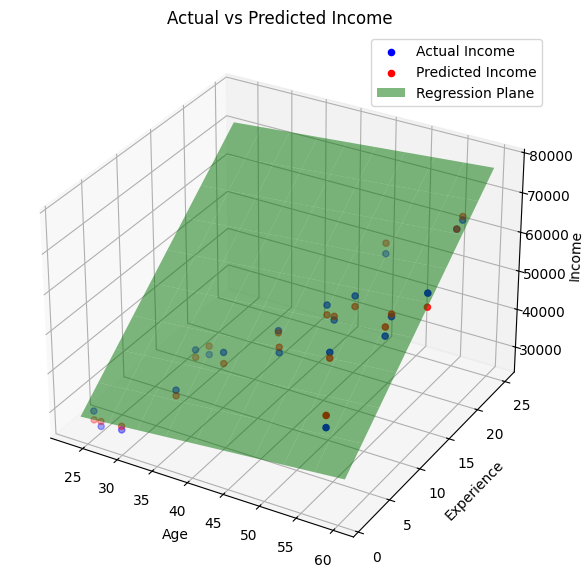

In [33]:
# Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual vs predicted income
ax.scatter(X_test['age'], X_test['experience'], y_test, color='blue', label='Actual Income')
ax.scatter(X_test['age'], X_test['experience'], y_pred, color='red', label='Predicted Income')

# Create a meshgrid for the regression plane
age_range = np.linspace(X['age'].min(), X['age'].max(), 10)
experience_range = np.linspace(X['experience'].min(), X['experience'].max(), 10)
age_grid, experience_grid = np.meshgrid(age_range, experience_range)

# Predict income values for the grid
income_grid = model.intercept_ + model.coef_[0] * age_grid + model.coef_[1] * experience_grid

# Regression plane
ax.plot_surface(age_grid, experience_grid, income_grid, color='green', alpha=0.5, label='Regression Plane')

# Labels and title
ax.set_title('Actual vs Predicted Income')
ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('Income')
ax.legend()